# Análise Tática e Estatística: Transição de Comando no Cruzeiro
**Tite vs. Arthur Jorge: Impactos na Criação, Finalização e Utilização da Base**

**Autor:** Felipe Almeida Pereira  
**Data:** Agosto de 2026  

---

## Resumo do Projeto
Este projeto dá uma olhada de perto nas mudanças práticas do Cruzeiro após a troca de comando técnico (de Tite para Arthur Jorge). 

Ao invés de uma análise genérica, o foco principal do trabalho é rastrear um **"efeito dominó"** tático. Utilizando dados do Sofascore de uma amostra de 8 jogos de cada treinador, nós vamos acompanhar a jornada da bola e investigar como o reposicionamento de um jogador na base da jogada impactou todo o resto do time:
1. **O Início da Cadeia:** A nova função tática de Gerson e o seu mapa de passes progressivos na saída de bola.
2. **O Efeito na Criação:** Como essa mudança na volância "desafogou" Matheus Pereira, dando liberdade para ele flutuar e criar na entrelinha.
3. **O Impacto na Finalização:** O reflexo direto disso no salto de letalidade e na qualidade das chances (xG e xA) que passaram a chegar no Kaio Jorge.

Por fim, saindo um pouco das quatro linhas e olhando para a gestão do elenco, o projeto traz uma **análise rápida sobre a utilização da base (Sub-23)**, comparando o espaço que os garotos ganharam com cada treinador em um recorte idêntico de 19 partidas.

## 1. Preparação do Ambiente
Instalação das bibliotecas necessárias para manipulação de dados, web scraping e desenho dos campos de futebol (pitches).

In [6]:
# Instalação das bibliotecas 
!pip install requests pandas matplotlib seaborn mplsoccer
!pip install cloudscraper

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mplsoccer import Pitch
from mplsoccer import VerticalPitch
from datetime import datetime

---
## 2. Análise Espacial: O Reposicionamento do Gerson
Nesta primeira etapa, extraímos as coordenadas de movimentação do Gerson através dos mapas de calor (*Heatmaps*) do Sofascore. 

Para garantir uma comparação justa, definimos uma amostra de 8 jogos para cada treinador: as 8 partidas mais recentes do Arthur Jorge no Brasileirão, e os 7 jogos do Tite no campeonato nacional somados à final do Campeonato Mineiro.

O gráfico de densidade (*KDE Plot*) abaixo ilustra visualmente as zonas do campo onde o jogador esteve mais ativo, revelando como a troca de comando impactou diretamente a sua liberdade de movimentação.

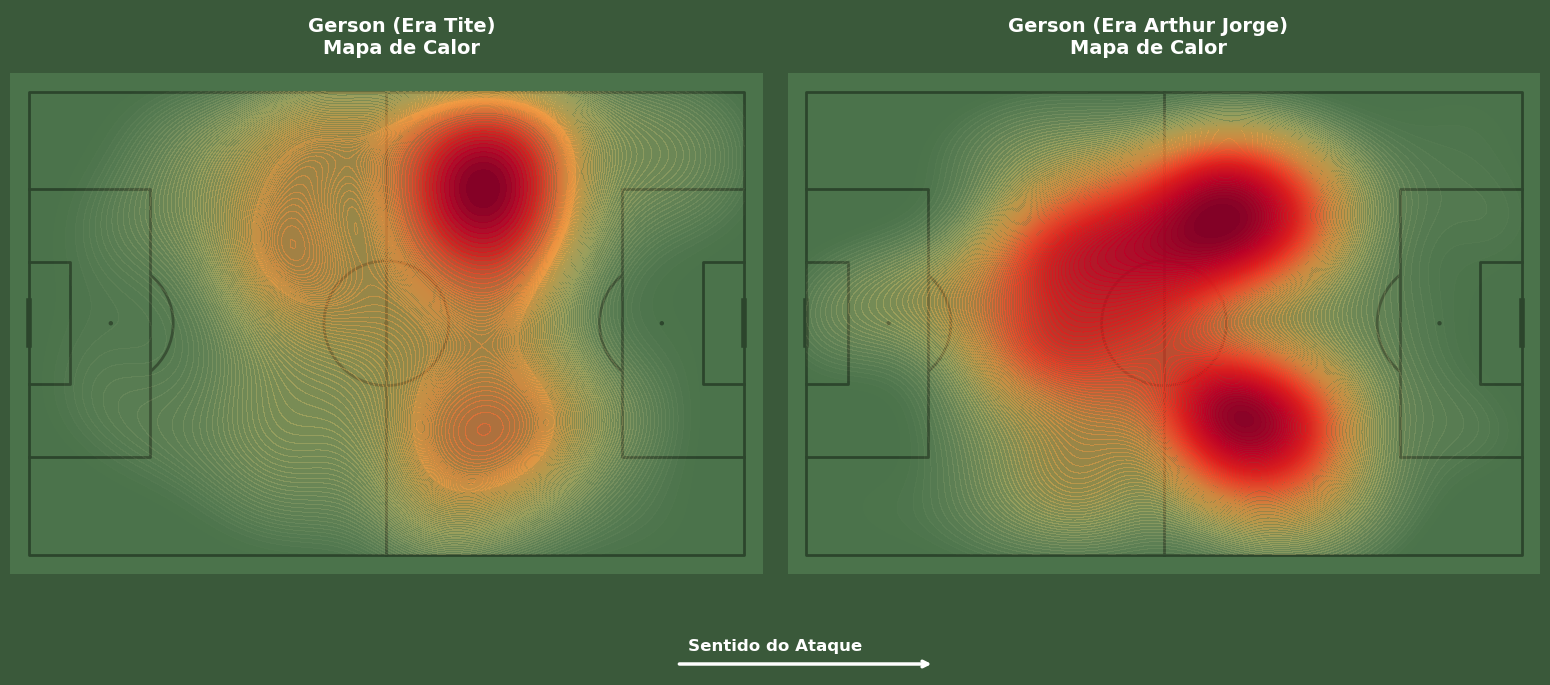

In [7]:
# ==========================================
# MAPA DE CALOR: GERSON (ESTILO SOFASCORE)
# ==========================================

# Agora usamos a função que busca o arquivo de Heatmap real (igual fizemos com o Matheus)
def agregar_coordenadas_heatmap(pasta, sigla, nome_busca):
    toques_x, toques_y = [], []
    
    for i in range(1, 9):
        nome_arquivo = f"jogo{i}_{sigla}_{nome_busca}_heatmap.json"
        caminho = os.path.join(pasta, nome_arquivo)
        
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                if 'heatmap' in dados:
                    for ponto in dados['heatmap']:
                        toques_x.append(ponto['x'])
                        toques_y.append(ponto['y'])
                        
    return toques_x, toques_y

x_tt, y_tt = agregar_coordenadas_heatmap('dados_tite', 'tt', 'gerson')
x_aj, y_aj = agregar_coordenadas_heatmap('dados_arthur', 'aj', 'gerson')

# ==========================================
# DESIGN SOFASCORE (Verde, sem curvas de nível)
# ==========================================
cor_grama = '#4b734b'
cor_linha = '#2c452c'

pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)
fig, axs = pitch.grid(ncols=2, title_height=0.08, endnote_space=0.08, axis=False, figheight=7)
fig.set_facecolor('#3a593a')

# Criando um mapa de cores gradual (Transparente -> Amarelo -> Laranja -> Vermelho)
cmap_base = plt.cm.YlOrRd
meu_cmap = cmap_base(np.arange(cmap_base.N))
meu_cmap[:, -1] = np.linspace(0.0, 1.0, cmap_base.N)
cmap_sofascore = mcolors.ListedColormap(meu_cmap)

# Plot Era Tite
pitch.kdeplot(x_tt, y_tt, ax=axs['pitch'][0],
              cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)

# Plot Era Arthur Jorge
pitch.kdeplot(x_aj, y_aj, ax=axs['pitch'][1],
              cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)

# Títulos
axs['title'].text(0.25, 0.5, 'Gerson (Era Tite)\nMapa de Calor', color='white', va='center', ha='center', fontsize=14, fontweight='bold')
axs['title'].text(0.75, 0.5, 'Gerson (Era Arthur Jorge)\nMapa de Calor', color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# Adicionando a Seta e Texto de Sentido do Ataque no rodapé
fig.text(0.5, 0.06, 'Sentido do Ataque', color='white', ha='center', fontsize=12, fontweight='bold')
plt.annotate('', xy=(0.58, 0.03), xytext=(0.42, 0.03), xycoords='figure fraction',
             arrowprops=dict(arrowstyle="->", color='white', lw=2.5))

plt.savefig('graficos/01_heatmap_gerson.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Insights Táticos: Liberdade e Flutuação
* **Era Tite (Esquerda):** o mapa mostra o Gerson mais “preso”, concentrado em um único corredor lateral — um 
padrão associado a menor participação na dinâmica geral do jogo.
* **Era Arthur Jorge (Direita):** mudança visível — as zonas de calor se espalham e o jogador passa a ocupar também 
a faixa central, um padrão associado a mais mobilidade e imprevisibilidade na construção de jogo.

---
## 3. O Efeito Dominó: O Mapa de Matheus Pereira
Para entender o impacto real da mudança de postura do Gerson, nós mantivemos exatamente a mesma amostra de partidas (os 8 jogos definidos para cada treinador). A ideia aqui é ver como a nova dinâmica na saída de bola afetou diretamente o camisa 10.

O mapa de calor abaixo mostra por onde o Matheus Pereira se movimentou nessas mesmas partidas, revelando uma mudança clara na forma como ele passou a ocupar os espaços no campo ofensivo.

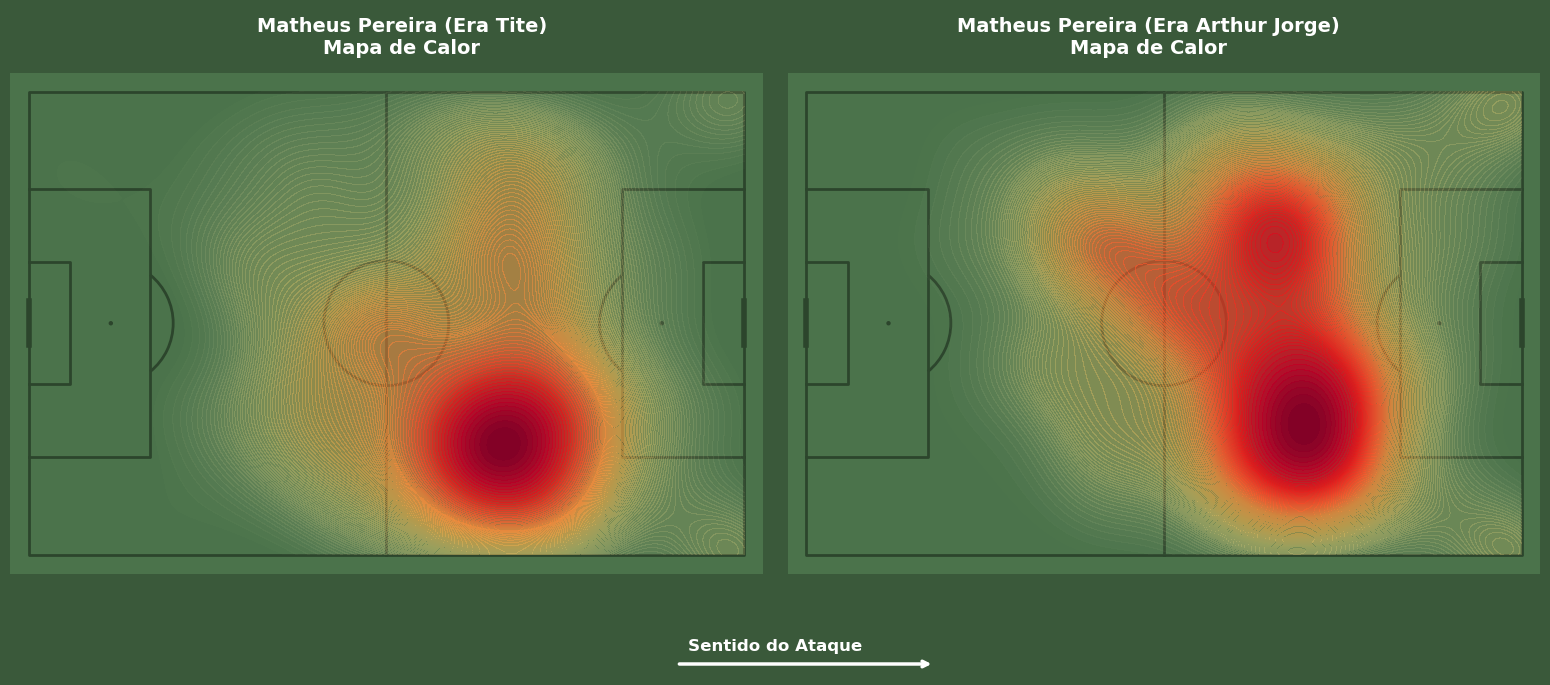

In [8]:
# ==========================================
# EXTRAINDO E DESENHANDO: MATHEUS PEREIRA (ESTILO SOFASCORE)
# ==========================================
# 1. Extraindo os dados
x_tite_mp, y_tite_mp = agregar_coordenadas_heatmap('dados_tite', 'tt', 'matheus')
x_arthur_mp, y_arthur_mp = agregar_coordenadas_heatmap('dados_arthur', 'aj', 'matheus')

# 2. Configurando o Pitch
cor_grama = '#4b734b'
cor_linha = '#2c452c'

pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)
fig_mp, axs_mp = pitch.grid(ncols=2, title_height=0.08, endnote_space=0.08, axis=False, figheight=7)
fig_mp.set_facecolor('#3a593a')

# Reconstruindo o mapa de cores gradual (Transparente -> Amarelo -> Vermelho)
cmap_base = plt.cm.YlOrRd
meu_cmap = cmap_base(np.arange(cmap_base.N))
meu_cmap[:, -1] = np.linspace(0.0, 1.0, cmap_base.N)
cmap_sofascore = mcolors.ListedColormap(meu_cmap)

# 3. Plotando a Era Tite (Campo da Esquerda)
if len(x_tite_mp) > 0:
    pitch.kdeplot(x_tite_mp, y_tite_mp, ax=axs_mp['pitch'][0], 
                  cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)
axs_mp['title'].text(0.25, 0.5, 'Matheus Pereira (Era Tite)\nMapa de Calor', 
                  color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# 4. Plotando a Era Arthur Jorge (Campo da Direita)
if len(x_arthur_mp) > 0:
    pitch.kdeplot(x_arthur_mp, y_arthur_mp, ax=axs_mp['pitch'][1], 
                  cmap=cmap_sofascore, fill=True, levels=100, thresh=0.02, cut=4)
axs_mp['title'].text(0.75, 0.5, 'Matheus Pereira (Era Arthur Jorge)\nMapa de Calor', 
                  color='white', va='center', ha='center', fontsize=14, fontweight='bold')

# 5. Adicionando a Seta e Texto de Sentido do Ataque no rodapé
fig_mp.text(0.5, 0.06, 'Sentido do Ataque', color='white', ha='center', fontsize=12, fontweight='bold')
plt.annotate('', xy=(0.58, 0.03), xytext=(0.42, 0.03), xycoords='figure fraction',
             arrowprops=dict(arrowstyle="->", color='white', lw=2.5))

plt.savefig('graficos/02_heatmap_matheus.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Insights Táticos: Ocupação de Espaços e Centralização
* **Era Tite (Esquerda):** Olhando o mapa, notamos que o raio de ação do Matheus Pereira era bem mais restrito. A mancha de calor é densa e quase exclusiva no lado direito da intermediária. Ele ficava muito fixo nesse setor, o que acabava limitando a sua presença em outras faixas do campo e deixando o nosso ataque mais previsível.
* **Era Arthur Jorge (Direita):** Aqui vemos o "efeito dominó" acontecendo. Com o time rodando a bola de outra forma lá trás, o Matheus passa a dominar o centro do campo. As manchas quentes mostram que ele começou a flutuar muito mais pela faixa central (na famosa entrelinha) e bem mais perto da entrada da área adversária. Ele deixa de ficar preso a uma lateral e se consolida na zona principal de criação.

---
## 4. Verticalidade e Participação: Passes Progressivos do Gerson
Já vimos que o Gerson passou a ter liberdade para flutuar no campo, mas como isso se traduziu na prática com a bola nos pés? O objetivo desta etapa é analisar o impacto dessa mudança no nível de participação dele na construção ofensiva.

O script a seguir filtra os passes certos do jogador e isola apenas aqueles que progridem em direção ao **terço final do campo** (representados pelas setas brancas). Em destaque (setas douradas), mapeamos os **Key Passes** (Passes Decisivos). Para alinhamento de conceito, segundo a própria metodologia do Sofascore, um passe chave é aquele que leva diretamente a uma finalização de um companheiro.

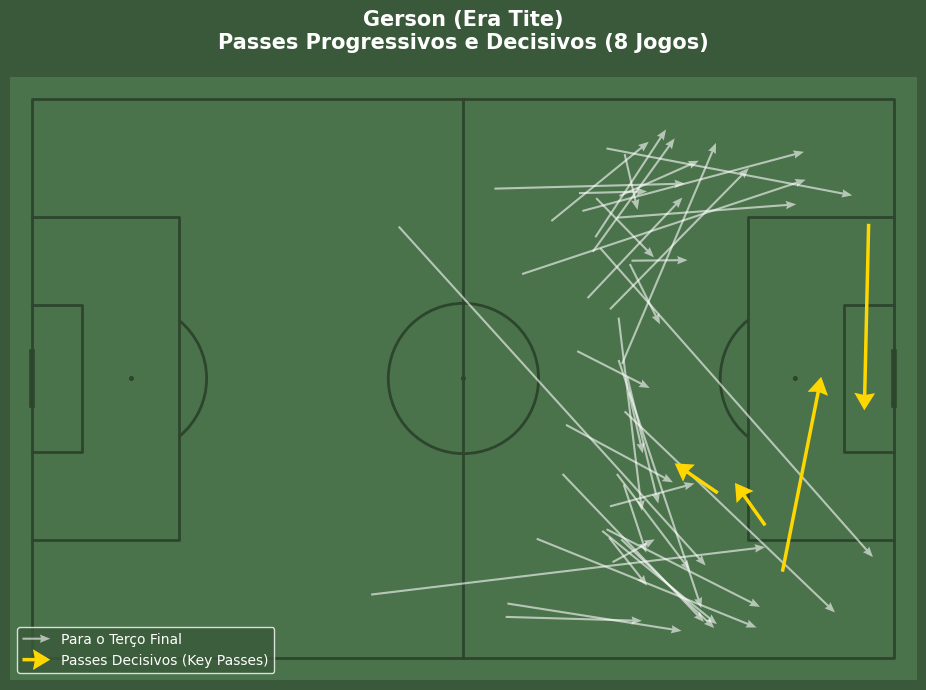

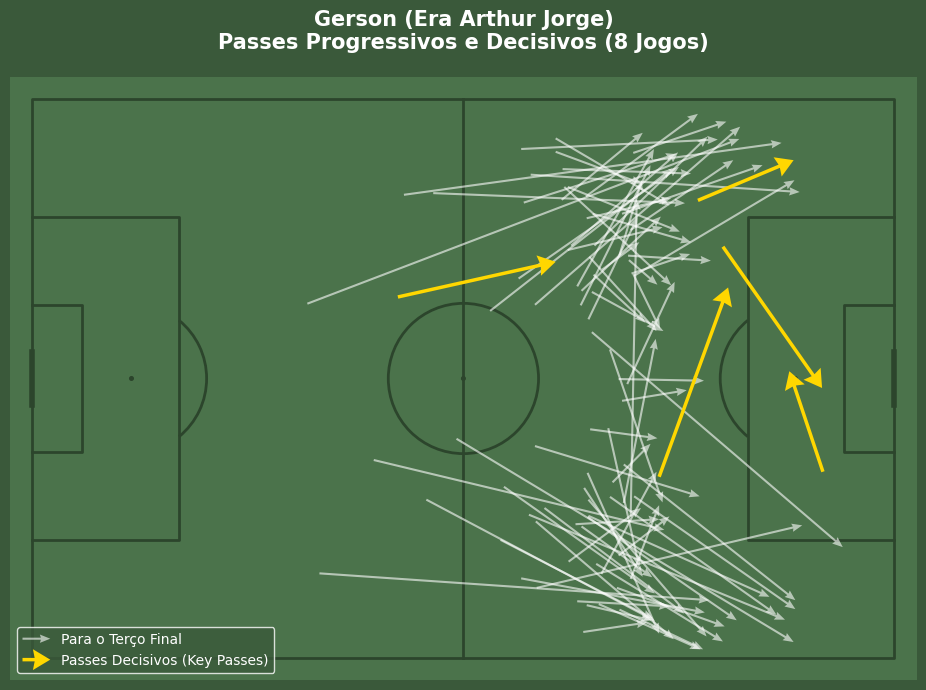

In [9]:
# ==========================================
# MAPA DE PASSES AGRESSIVOS: GERSON (AS DUAS ERAS)
# ==========================================

# ==========================================
# FUNÇÃO DE EXTRAÇÃO DE PASSES (ESCALÁVEL)
# ==========================================
def extrair_passes_verticais(pasta, sigla, nome_busca):
    passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim = [], [], [], []
    key_x_ini, key_y_ini, key_x_fim, key_y_fim = [], [], [], []
    
    for i in range(1, 9):
        # O nome do arquivo agora é gerado dinamicamente com o nome_busca
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_{nome_busca}_passes.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                for evento in dados.get('passes', []):
                    # Filtrar apenas passes que deram certo
                    if evento.get('outcome') == True:
                        x_ini = evento['playerCoordinates']['x']
                        y_ini = evento['playerCoordinates']['y']
                        x_fim = evento['passEndCoordinates']['x']
                        y_fim = evento['passEndCoordinates']['y']
                        
                        # Destacar Passes Decisivos (Key Passes)
                        if evento.get('keypass') == True:
                            key_x_ini.append(x_ini)
                            key_y_ini.append(y_ini)
                            key_x_fim.append(x_fim)
                            key_y_fim.append(y_fim)
                        # Filtrar passes que quebram linhas para o terço final (X final > 70)
                        elif x_fim > 70 and x_ini < 70:  # Adicionando condição para passes que quebram linhas
                            passes_x_ini.append(x_ini)
                            passes_y_ini.append(y_ini)
                            passes_x_fim.append(x_fim)
                            passes_y_fim.append(y_fim)

    return (passes_x_ini, passes_y_ini, passes_x_fim, passes_y_fim, 
            key_x_ini, key_y_ini, key_x_fim, key_y_fim)

# ==========================================
# PLOT: PASSES PROGRESSIVOS E DECISIVOS
# ==========================================

# 1. Extração dos dados usando a função genérica
dados_tt = extrair_passes_verticais('dados_tite', 'tt', 'gerson')
dados_aj = extrair_passes_verticais('dados_arthur', 'aj', 'gerson')

# 2. Configuração de Design Sofascore
cor_grama = '#4b734b'
cor_linha = '#2c452c'
cor_fundo = '#3a593a'
pitch = Pitch(pitch_type='opta', pitch_color=cor_grama, line_color=cor_linha)

# 3. Dicionário para iterar os cenários sem repetir código de plotagem
cenarios = [
    {'sigla': 'tt', 'dados': dados_tt, 'titulo': 'Gerson (Era Tite)\nPasses Progressivos e Decisivos (8 Jogos)'},
    {'sigla': 'aj', 'dados': dados_aj, 'titulo': 'Gerson (Era Arthur Jorge)\nPasses Progressivos e Decisivos (8 Jogos)'}
]

# 4. Gerando os gráficos independentes
for cenario in cenarios:
    fig, ax = pitch.draw(figsize=(10, 7))
    fig.set_facecolor(cor_fundo)
    
    # Desempacotando as coordenadas
    (p_x_ini, p_y_ini, p_x_fim, p_y_fim, 
     k_x_ini, k_y_ini, k_x_fim, k_y_fim) = cenario['dados']
    
    # Plotando passes progressivos (Brancos)
    pitch.arrows(p_x_ini, p_y_ini, p_x_fim, p_y_fim,
                 ax=ax, width=1.5, headwidth=4, color='white', alpha=0.6, label='Para o Terço Final')
    
    # Plotando Passes Decisivos (Dourados)
    pitch.arrows(k_x_ini, k_y_ini, k_x_fim, k_y_fim,
                 ax=ax, width=2.5, headwidth=6, color='#ffd700', alpha=1.0, label='Passes Decisivos (Key Passes)')
    
    ax.legend(facecolor=cor_fundo, edgecolor='white', labelcolor='white', loc='lower left')
    plt.title(cenario['titulo'], color='white', size=15, pad=20, fontweight='bold')
    
    # Salvando a imagem na pasta com o nome dinâmico
    plt.savefig(f"graficos/03_passes_gerson_{cenario['sigla']}.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

### Insights Táticos: O Salto no Volume de Jogo
* **Era Tite (Primeiro Gráfico):** o Gerson já executava lançamentos e passes de ruptura, mas com menor frequência.
* **Era Arthur Jorge (Segundo Gráfico):** o volume de passes progressivos aumenta visivelmente, assim como o número de *Key Passes* — um indício de que o jogador passou a ter papel mais central na construção vertical da equipe. 

---
## 5. O Fim da Cadeia: Mapa de Finalizações de Kaio Jorge
Para fechar esse mapeamento do "efeito dominó" causado pelo reposicionamento do Gerson, mantivemos a nossa lupa sobre a mesma amostra de 8 partidas, mas agora olhando para a ponta final do ataque. 

Se a bola ganha verticalidade na defesa e passa a transitar pela zona central de criação, o reflexo prático tem que aparecer no homem de referência. O gráfico abaixo plota as coordenadas de todos os chutes do Kaio Jorge (excluindo pênaltis) nos mesmos jogos analisados. O **tamanho do círculo é proporcional ao xG (Gols Esperados)** da chance, e os círculos amarelos representam os gols marcados.

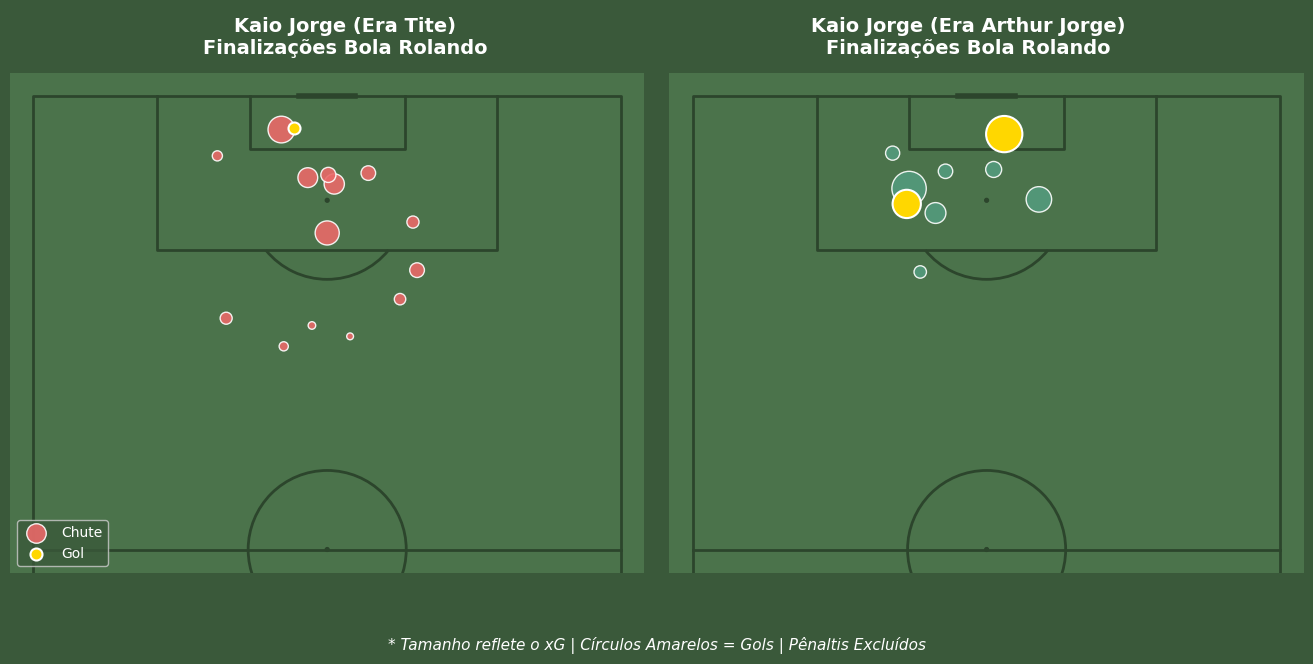

In [10]:
# ==========================================
# MAPA DE FINALIZAÇÕES E xG: KAIO JORGE
# ==========================================

def extrair_chutes_xg_avancado(pasta, sigla, nome_busca):
    x_ng, y_ng, xg_ng = [], [], []
    x_g, y_g, xg_g = [], [], []
    
    for i in range(1, 9):
        # Caminho gerado dinamicamente com o nome do jogador
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_{nome_busca}_shots.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                try:
                    dados = json.load(f)
                    for chute in dados.get('shotmap', []):
                        if chute.get('situation') == 'penalty':
                            continue
                            
                        coord = chute.get('playerCoordinates', {})
                        x_original = coord.get('x')
                        y = coord.get('y')
                        xg_valor = chute.get('xg', 0.05)
                        
                        if x_original is not None and y is not None:
                            x_invertido = 100 - x_original
                            tamanho = xg_valor * 1500
                            
                            if chute.get('shotType') == 'goal':
                                x_g.append(x_invertido)
                                y_g.append(y)
                                xg_g.append(tamanho)
                            else:
                                x_ng.append(x_invertido)
                                y_ng.append(y)
                                xg_ng.append(tamanho)
                except json.JSONDecodeError:
                    continue
                    
    return x_ng, y_ng, xg_ng, x_g, y_g, xg_g

# ==========================================
# PLOT: MAPA DE FINALIZAÇÕES E xG
# ==========================================

# 1. Extraindo os dados passando 'kaio' como parâmetro de busca
x_ng_tt, y_ng_tt, xg_ng_tt, x_g_tt, y_g_tt, xg_g_tt = extrair_chutes_xg_avancado('dados_tite', 'tt', 'kaio')
x_ng_aj, y_ng_aj, xg_ng_aj, x_g_aj, y_g_aj, xg_g_aj = extrair_chutes_xg_avancado('dados_arthur', 'aj', 'kaio')

# 2. Configurando o desenho com a paleta Verde Sofascore
cor_grama = '#4b734b'
cor_linha = '#2c452c'
cor_fundo = '#3a593a'

pitch = VerticalPitch(pitch_type='opta', half=True, pitch_color=cor_grama, line_color=cor_linha)
fig, axs = pitch.grid(ncols=2, title_height=0.08, endnote_space=0, axis=False, figheight=7)
fig.set_facecolor(cor_fundo)

# 3. PLOT: ERA TITE
pitch.scatter(x_ng_tt, y_ng_tt, s=xg_ng_tt, c='#ea6969', edgecolors='white', linewidths=1, alpha=0.9, ax=axs['pitch'][0], zorder=3, label='Chute')
pitch.scatter(x_g_tt, y_g_tt, s=xg_g_tt, c='#ffd700', edgecolors='white', linewidths=1.5, alpha=1.0, ax=axs['pitch'][0], zorder=4, label='Gol')
axs['title'].text(0.25, 0.5, 'Kaio Jorge (Era Tite)\nFinalizações Bola Rolando', color='white', va='center', ha='center', fontsize=14, fontweight='bold')
axs['pitch'][0].legend(loc='lower left', facecolor=cor_fundo, edgecolor='#cccccc', labelcolor='white')

# 4. PLOT: ERA ARTHUR JORGE
pitch.scatter(x_ng_aj, y_ng_aj, s=xg_ng_aj, c='#539b7c', edgecolors='white', linewidths=1, alpha=0.9, ax=axs['pitch'][1], zorder=3)
pitch.scatter(x_g_aj, y_g_aj, s=xg_g_aj, c='#ffd700', edgecolors='white', linewidths=1.5, alpha=1.0, ax=axs['pitch'][1], zorder=4)
axs['title'].text(0.75, 0.5, 'Kaio Jorge (Era Arthur Jorge)\nFinalizações Bola Rolando', color='white', va='center', ha='center', fontsize=14, fontweight='bold')

fig.text(0.5, 0.02, '* Tamanho reflete o xG | Círculos Amarelos = Gols | Pênaltis Excluídos', color='white', ha='center', fontsize=11, fontstyle='italic')
plt.savefig('graficos/04_shotmap_kaio.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Insights Táticos: A Zona de Ouro
* **Era Tite (Esquerda):** maior dispersão nas finalizações, com vários chutes de fora da área ou em ângulos fechados — círculos menores, refletindo xG mais baixo. 
* **Era Arthur Jorge (Direita):** concentração maior de finalizações na “zona de ouro” (próximo à marca do pênalti e dentro da pequena área). Os círculos maiores indicam chances de melhor qualidade chegando ao atacante.

---
## 6. Comprovação Estatística: Volume e Criação (Por 90 Minutos)
Os mapas espaciais nos deram o contexto visual das mudanças táticas. Agora, precisamos da validação matemática. 

Para manter a consistência da nossa análise do "efeito dominó", processamos os relatórios completos (Lineups) daquelas mesmas 8 partidas exatas de cada treinador. O objetivo é extrair o volume de jogo real dos nossos três "personagens" nesse recorte. E para garantir que a comparação seja 100% justa (já que o tempo em campo de cada um varia), nós normalizamos todas as métricas para **valores por 90 minutos jogados (p90)**.

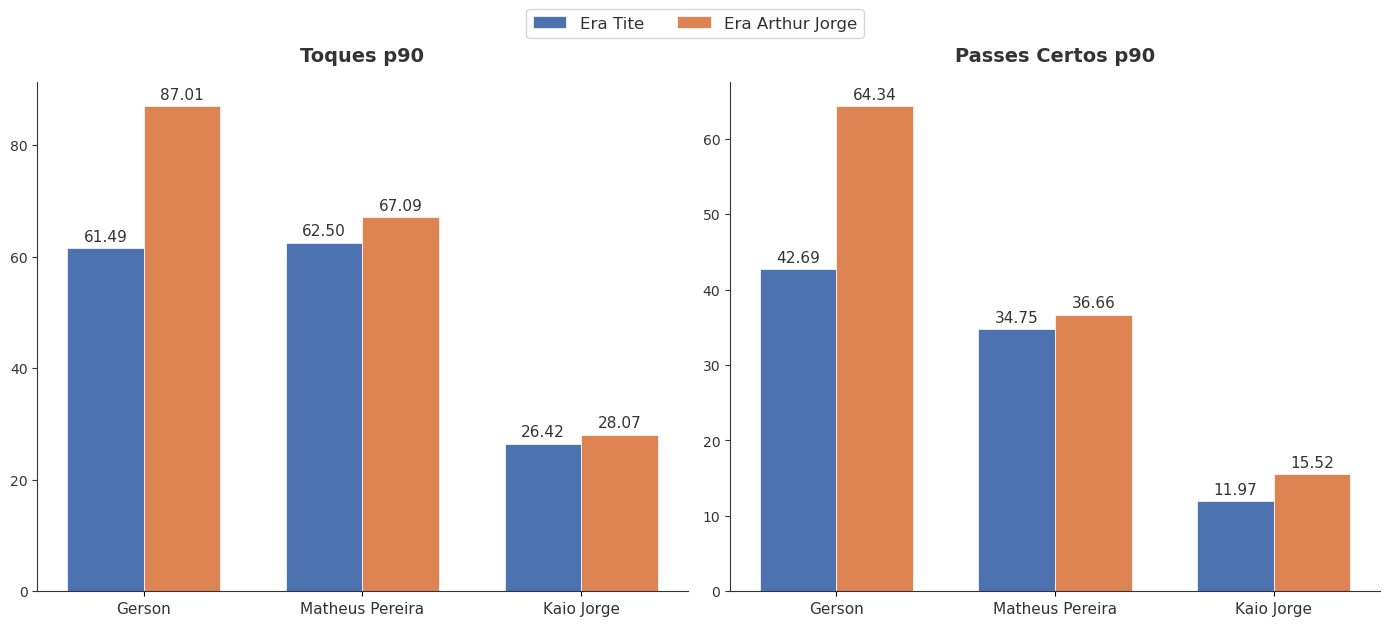

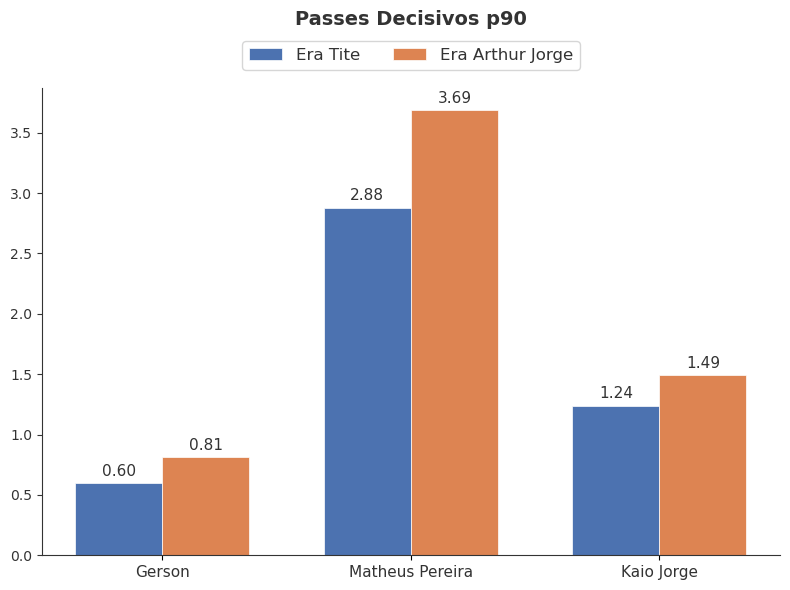

In [11]:
def calcular_medias_p90(pasta, sigla, nome_busca):
    total_minutos = 0
    total_toques = 0
    total_keypasses = 0
    total_passes = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                # Junta os jogadores dos dois times para buscar
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    # Busca o jogador pelo nome ignorando maiúsculas
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        total_minutos += stats.get('minutesPlayed', 0)
                        total_toques += stats.get('touches', 0)
                        total_keypasses += stats.get('keyPass', 0)
                        total_passes += stats.get('accuratePass', 0)
                        
    # Calculando a métrica p90 (por 90 minutos)
    if total_minutos > 0:
        toques_p90 = round((total_toques / total_minutos) * 90, 2)
        keypasses_p90 = round((total_keypasses / total_minutos) * 90, 2)
        passes_p90 = round((total_passes / total_minutos) * 90, 2)
    else:
        toques_p90 = keypasses_p90 = passes_p90 = 0
        
    return [toques_p90, passes_p90, keypasses_p90]

# Jogadores que vamos analisar
jogadores = ['Gerson', 'Matheus Pereira', 'Kaio Jorge']
resultados = []

for jogador in jogadores:
    stats_tite = calcular_medias_p90('dados_tite', 'tt', jogador)
    stats_arthur = calcular_medias_p90('dados_arthur', 'aj', jogador)
    
    resultados.append({
        'Jogador': jogador,
        'Toques p90 (Tite)': stats_tite[0],
        'Toques p90 (Arthur)': stats_arthur[0],
        'Passes Certos p90 (Tite)': stats_tite[1],
        'Passes Certos p90 (Arthur)': stats_arthur[1],
        'Passes Decisivos p90 (Tite)': stats_tite[2],
        'Passes Decisivos p90 (Arthur)': stats_arthur[2]
    })

df_final = pd.DataFrame(resultados)

# ==========================================
# PLOT 1: VOLUME DE JOGO (Toques e Passes Certos)
# ==========================================
cor_fundo = '#ffffff'    
cor_tite = '#4c72b0'     
cor_arthur = '#dd8452'   
cor_texto = '#333333'    

x = np.arange(len(jogadores))  
width = 0.35  

# Criando figura com 2 gráficos lado a lado (tamanho ajustado para caber bem no PDF)
fig1, axs1 = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo)

metricas_volume = [
    ('Toques p90', 'Toques p90 (Tite)', 'Toques p90 (Arthur)'),
    ('Passes Certos p90', 'Passes Certos p90 (Tite)', 'Passes Certos p90 (Arthur)')
]

for i, (titulo, col_tite, col_arthur) in enumerate(metricas_volume):
    ax = axs1[i]
    ax.set_facecolor(cor_fundo)
    
    barras_tite = ax.bar(x - width/2, df_final[col_tite], width, label='Era Tite', color=cor_tite, edgecolor='white', linewidth=0.5)
    barras_arthur = ax.bar(x + width/2, df_final[col_arthur], width, label='Era Arthur Jorge', color=cor_arthur, edgecolor='white', linewidth=0.5)
    
    ax.set_title(titulo, color=cor_texto, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(jogadores, color=cor_texto, fontsize=11)
    ax.tick_params(axis='y', colors=cor_texto)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(cor_texto)
    ax.spines['bottom'].set_color(cor_texto)
    
    for barra in barras_tite + barras_arthur:
        altura = barra.get_height()
        ax.annotate(f'{altura:.2f}',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', color=cor_texto, fontsize=11)

handles, labels = axs1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, 
           facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=12)

plt.tight_layout()
plt.savefig('graficos/05_barras_volume.png', dpi=300, bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()

# ==========================================
# PLOT 2: CRIAÇÃO (Passes Decisivos)
# ==========================================
# Criando figura isolada
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor=cor_fundo)
ax2.set_facecolor(cor_fundo)

barras_tite_decisivos = ax2.bar(x - width/2, df_final['Passes Decisivos p90 (Tite)'], width, label='Era Tite', color=cor_tite, edgecolor='white', linewidth=0.5)
barras_arthur_decisivos = ax2.bar(x + width/2, df_final['Passes Decisivos p90 (Arthur)'], width, label='Era Arthur Jorge', color=cor_arthur, edgecolor='white', linewidth=0.5)

# CORREÇÃO 1: Aumentamos o 'pad' para 45 (empurra o título bem para cima)
ax2.set_title('Passes Decisivos p90', color=cor_texto, fontsize=14, fontweight='bold', pad=45)
ax2.set_xticks(x)
ax2.set_xticklabels(jogadores, color=cor_texto, fontsize=11)
ax2.tick_params(axis='y', colors=cor_texto)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(cor_texto)
ax2.spines['bottom'].set_color(cor_texto)

for barra in barras_tite_decisivos + barras_arthur_decisivos:
    altura = barra.get_height()
    ax2.annotate(f'{altura:.2f}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', color=cor_texto, fontsize=11)

# CORREÇÃO 2: Mudamos o 'loc' e o 'bbox' para a legenda encaixar entre o título e o gráfico
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, 
           facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=12)

plt.tight_layout()
plt.savefig('graficos/05_barras_criacao.png', dpi=300, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()

### Insights Táticos: Protagonismo e Eficiência
* **O Novo Maestro (Gerson):** o aumento nos *Toques p90* (61,49 → 87,01) e nos *Passes Certos p90* acompanha o padrão observado nos mapas espaciais, reforçando a leitura de que ele passou a concentrar mais a saída de bola.
* **A Eficiência de Matheus Pereira:** o total de toques quase não muda (62,50 → 67,09), mas os *Passes Decisivos p90* sobem de 2,88 para 3,69 — um ganho de eficiência: com volume parecido de ações, ele passou a gerar mais chances reais de finalização.

---
## 7. Qualidade das Chances (xG e xA): O Peso de Cada Ação
Como vimos no gráfico anterior, o volume de passes decisivos do Matheus Pereira aumentou. Mas no futebol, mais do que criar muito, é preciso criar com qualidade. 

Para amarrar a nossa análise do "efeito dominó" nessas mesmas 8 partidas, calculamos os Gols Esperados (xG) e as Assistências Esperadas (xA) acumulados. Essa métrica avalia o nível de perigo real imposto ao adversário, revelando a probabilidade matemática de um passe ou chute resultar em gol. Isso nos ajuda a avaliar o desempenho tático puro, tirando da equação fatores aleatórios como "sorte" ou o goleiro adversário fazendo milagres.

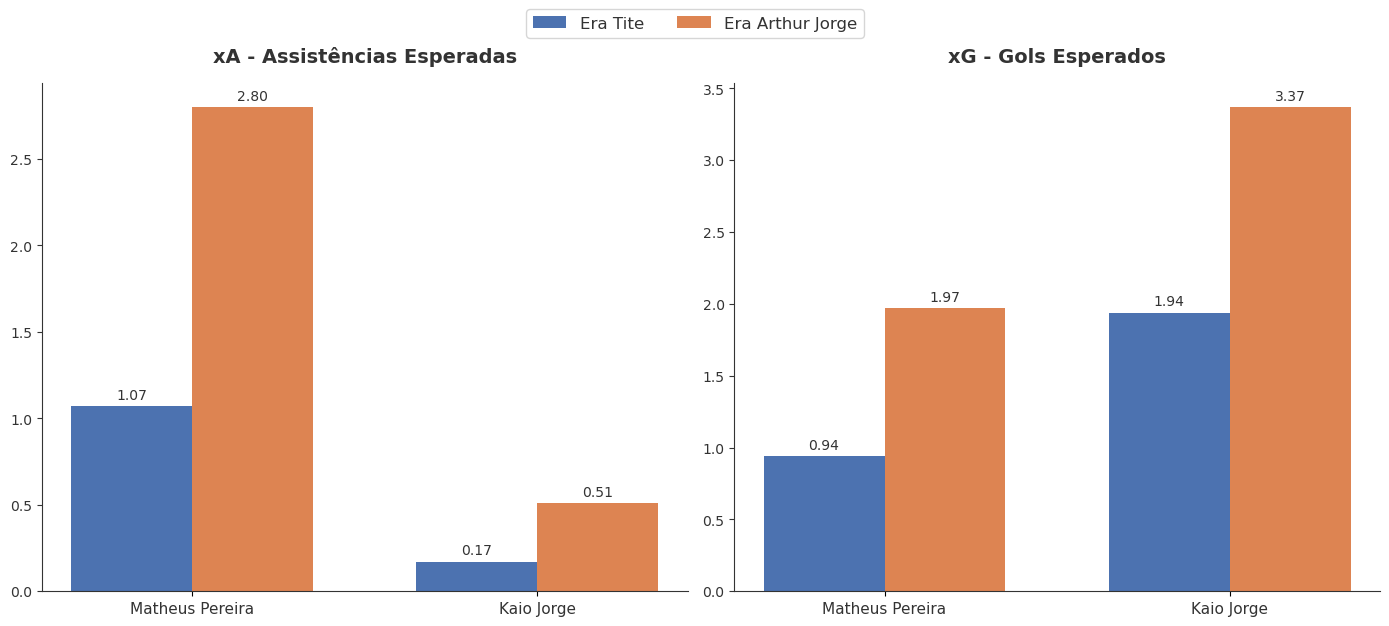

In [12]:
def calcular_xg_xa(pasta, sigla, nome_busca):
    total_xg = 0
    total_xa = 0
    
    for i in range(1, 9):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                dados = json.load(f)
                
                jogadores = dados['home']['players'] + dados['away']['players']
                
                for j in jogadores:
                    if nome_busca.lower() in j['player']['name'].lower():
                        stats = j.get('statistics', {})
                        # Somando as métricas de qualidade de chance
                        total_xg += stats.get('expectedGoals', 0)
                        total_xa += stats.get('expectedAssists', 0)
                        
    return total_xg, total_xa

# Vamos focar na dupla de definição: Matheus Pereira e Kaio Jorge
jogadores_ataque = ['Matheus Pereira', 'Kaio Jorge']
resultados_avancados = []

for jogador in jogadores_ataque:
    xg_tite, xa_tite = calcular_xg_xa('dados_tite', 'tt', jogador)
    xg_arthur, xa_arthur = calcular_xg_xa('dados_arthur', 'aj', jogador)
    
    resultados_avancados.append({
        'Jogador': jogador,
        'xA - Assist. Esperadas (Tite)': round(xa_tite, 2),
        'xA - Assist. Esperadas (Arthur)': round(xa_arthur, 2),
        'xG - Gols Esperados (Tite)': round(xg_tite, 2),
        'xG - Gols Esperados (Arthur)': round(xg_arthur, 2)
    })

# Transformando em DataFrame (Oculto para apresentação em Dashboard)
df_avancado = pd.DataFrame(resultados_avancados)

# ==========================================
# PLOT: PAINEL CORPORATIVO xG / xA
# ==========================================
cor_fundo = '#ffffff'
cor_tite = '#4c72b0'
cor_arthur = '#dd8452'
cor_texto = '#333333'

jogadores_xg = df_avancado['Jogador'].tolist()
x = np.arange(len(jogadores_xg))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo)

metricas_xg = [
    ('xA - Assistências Esperadas', 'xA - Assist. Esperadas (Tite)', 'xA - Assist. Esperadas (Arthur)'),
    ('xG - Gols Esperados', 'xG - Gols Esperados (Tite)', 'xG - Gols Esperados (Arthur)')
]

for i, (titulo, col_tite, col_arthur) in enumerate(metricas_xg):
    ax = axs[i]
    ax.set_facecolor(cor_fundo)
    
    barras_tite = ax.bar(x - width/2, df_avancado[col_tite], width, label='Era Tite', color=cor_tite)
    barras_arthur = ax.bar(x + width/2, df_avancado[col_arthur], width, label='Era Arthur Jorge', color=cor_arthur)
    
    ax.set_title(titulo, color=cor_texto, fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(jogadores_xg, color=cor_texto, fontsize=11)
    ax.tick_params(axis='y', colors=cor_texto)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(cor_texto)
    ax.spines['bottom'].set_color(cor_texto)
    
    for barra in barras_tite + barras_arthur:
        altura = barra.get_height()
        ax.annotate(f'{altura:.2f}', xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color=cor_texto, fontsize=10)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, 
           facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=12)

plt.tight_layout()
plt.savefig('graficos/06_barras_qualidade.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Insights Táticos: O Salto de Letalidade
* **A Mente Criativa (Matheus Pereira):** o **xA (Assistências Esperadas)** salta de 1,07 para 2,80 — reforçando a leitura de que os passes do meia passaram a colocar os companheiros em situações de gol mais claras. 
* **O Fim da Cadeia (Kaio Jorge):** o **xG (Gols Esperados)** vai de 1,94 para 3,37 no mesmo recorte — a probabilidade média de gol nas finalizações do atacante quase dobra, um indício de que as chances construídas pelo time chegam com mais qualidade ao homem de referência. 

---
## 8. Gestão de Ativos: A Utilização da Base (Sub-23)
Para finalizar nossa análise, saímos um pouco do campo tático e olhamos para um pilar estratégico e financeiro fundamental para o clube: o desenvolvimento de jovens talentos. 

Para evitar o viés de amostragem (já que a análise anterior focou nos jogos de titulares específicos), expandimos nossa extração para coletar os *Lineups* (escalações e substituições) de **19 partidas exatas de cada treinador**. O objetivo aqui é ter uma comparação absolutamente justa do espaço e do tempo de jogo dado aos garotos da categoria Sub-23.

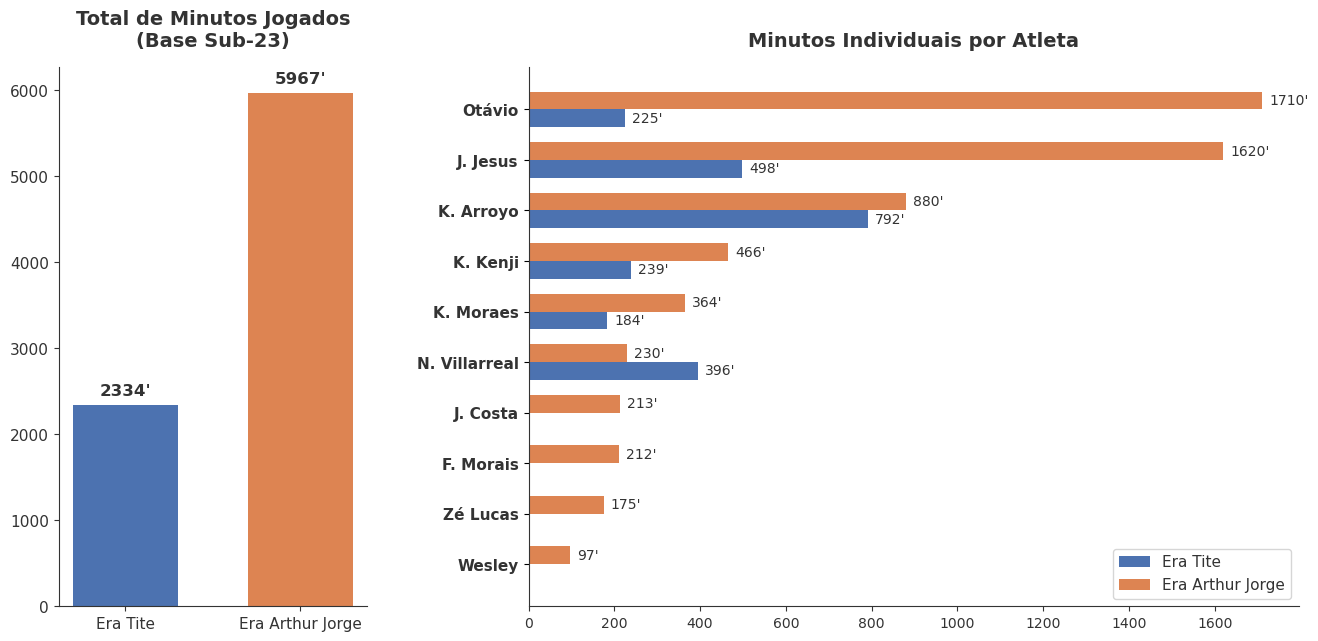

In [13]:
# ==========================================
# EXTRAÇÃO E CÁLCULO: UTILIZAÇÃO DA BASE SUB-23
# ==========================================

# 1. Função embutida para extrair a minutagem de forma independente
def extrair_minutos_base_agrupado(pasta, sigla, num_jogos, data_referencia):
    cruzeiro_id = 1954
    minutos_por_jogador = {}
    
    for i in range(1, num_jogos + 1):
        caminho = os.path.join(pasta, f"jogo{i}_{sigla}_lineups.json")
        if os.path.exists(caminho):
            with open(caminho, 'r', encoding='utf-8') as f:
                try:
                    dados = json.load(f)
                    jogadores = dados.get('home', {}).get('players', []) + dados.get('away', {}).get('players', [])
                    
                    for j in jogadores:
                        if j.get('teamId') == cruzeiro_id:
                            minutos = j.get('statistics', {}).get('minutesPlayed', 0)
                            if minutos > 0:
                                nascimento_timestamp = j['player'].get('dateOfBirthTimestamp')
                                if nascimento_timestamp:
                                    data_nascimento = datetime.fromtimestamp(nascimento_timestamp)
                                    idade = (data_referencia - data_nascimento).days / 365.25
                                    
                                    if idade <= 23:
                                        nome = j['player'].get('shortName', j['player'].get('name'))
                                        minutos_por_jogador[nome] = minutos_por_jogador.get(nome, 0) + minutos
                except json.JSONDecodeError:
                    continue
                    
    return dict(sorted(minutos_por_jogador.items(), key=lambda item: item[1]))

# Calculando as idades com base na data do projeto
data_atual = datetime(2026, 8, 21)

# Gerando os dicionários base_tite e base_arthur (exatamente 19 jogos)
base_tite = extrair_minutos_base_agrupado('lineup_tite', 'tt', 19, data_atual)
base_arthur = extrair_minutos_base_agrupado('lineup_arthur', 'aj', 19, data_atual)

# ==========================================
# PLOT: PAINEL DA BASE (BARRAS DUPLAS)
# ==========================================

# Cores (Padrão Corporativo Clássico)
cor_fundo = '#ffffff'
cor_tite = '#4c72b0'
cor_arthur = '#dd8452'
cor_texto = '#333333'

total_tite = sum(base_tite.values())
total_arthur = sum(base_arthur.values())

todos_jogadores = list(set(base_tite.keys()).union(set(base_arthur.keys())))
dados_jogadores = {
    'Jogador': todos_jogadores,
    'Tite': [base_tite.get(j, 0) for j in todos_jogadores],
    'Arthur Jorge': [base_arthur.get(j, 0) for j in todos_jogadores]
}
df_jogadores = pd.DataFrame(dados_jogadores)
df_jogadores = df_jogadores.sort_values(by=['Arthur Jorge', 'Tite'], ascending=True)

fig = plt.figure(figsize=(16, 7), facecolor=cor_fundo)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.5], wspace=0.3)

# GRÁFICO 1: TOTAL DE MINUTOS (Esquerda)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(cor_fundo)

barras_total = ax1.bar(['Era Tite', 'Era Arthur Jorge'], [total_tite, total_arthur], 
                       color=[cor_tite, cor_arthur], width=0.6)

ax1.set_title('Total de Minutos Jogados\n(Base Sub-23)', color=cor_texto, fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(colors=cor_texto, labelsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(cor_texto)
ax1.spines['bottom'].set_color(cor_texto)

for barra in barras_total:
    altura = barra.get_height()
    ax1.annotate(f"{int(altura)}'", 
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', color=cor_texto, fontsize=12, fontweight='bold')

# GRÁFICO 2: MINUTOS POR JOGADOR (Direita)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(cor_fundo)

y = np.arange(len(df_jogadores))
altura_barra = 0.35

barras_j_tite = ax2.barh(y - altura_barra/2, df_jogadores['Tite'], altura_barra, label='Era Tite', color=cor_tite)
barras_j_arthur = ax2.barh(y + altura_barra/2, df_jogadores['Arthur Jorge'], altura_barra, label='Era Arthur Jorge', color=cor_arthur)

ax2.set_title('Minutos Individuais por Atleta', color=cor_texto, fontsize=14, fontweight='bold', pad=15)
ax2.set_yticks(y)
ax2.set_yticklabels(df_jogadores['Jogador'], color=cor_texto, fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', colors=cor_texto)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(cor_texto)
ax2.spines['bottom'].set_color(cor_texto)

for barra in barras_j_tite + barras_j_arthur:
    largura = barra.get_width()
    if largura > 0:
        ax2.annotate(f"{int(largura)}'", 
                     xy=(largura, barra.get_y() + barra.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     ha='left', va='center', color=cor_texto, fontsize=10)

ax2.legend(loc='lower right', facecolor=cor_fundo, edgecolor='#cccccc', labelcolor=cor_texto, fontsize=11)
plt.savefig('graficos/07_barras_base.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Insights Táticos: A Valorização do DNA do Clube
* **Volume Absoluto (Esquerda):** no mesmo recorte de 19 jogos, a Era Arthur Jorge soma mais que o dobro de minutagem para os jovens (5.967' contra 2.334'). 
* **Democratização das Oportunidades (Direita):** o aumento não se concentra em um ou dois nomes — jogadores como J. Costa, F. Morais, Zé Lucas e Wesley também ganharam minutos, ampliando o leque de opções do elenco. 

## Conclusão
No recorte estudado, a troca de comando coincide com mudanças espaciais e estatísticas que percorrem 
diferentes etapas da construção ofensiva: maior participação progressiva de Gerson, maior 
centralização de Matheus Pereira e finalizações de maior valor por parte de Kaio Jorge. Em paralelo, a 
utilização de atletas Sub-23 também cresce de forma expressiva na amostra ampliada. 
A principal contribuição do estudo é organizar esses sinais em uma única narrativa — o “Efeito 
Dominó” — sem transformar uma comparação observacional em uma afirmação causal.

## Limites da leitura
Os resultados dependem do recorte escolhido e dos eventos registrados pelo Sofascore. A análise identifica diferenças entre os períodos, mas não controla de forma experimental fatores como adversário, mando de campo, estado do jogo ou outras alterações no elenco. Por isso, as conclusões devem ser lidas como evidências descritivas e hipóteses táticas.